## Proyecto de Segmentación de Pacientes — Big Data 2
## Carrera: Ciencia de Datos

Este notebook está dividido en 4 bloques bien separados:

1. **Preparación y carga de datos**
2. **Exploración y limpieza (Data Wrangling)**
3. **Gráficos y análisis exploratorio (EDA)** — cada gráfico explica qué se ve y su conclusión
4. **Entrenamiento de modelos (Machine Learning)**


---
## 1.  Preparación y Carga de Datos

Importamos las librerías necesarias y cargamos el archivo CSV con los datos de los pacientes.

- `pandas` → manipulación de tablas (DataFrames)
- `numpy` → cálculos numéricos
- `matplotlib` / `seaborn` → visualización gráfica
- `scikit-learn` → algoritmos de Machine Learning


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, silhouette_score

sns.set_theme(style='whitegrid')

df = pd.read_csv('data/patient_segmentation_dataset.csv')
print(f'Dataset cargado: {df.shape[0]} pacientes, {df.shape[1]} columnas')
df.head()

Dataset cargado: 2000 pacientes, 16 columnas


,PatientID,Age,Gender,State,City,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Last_Visit_Date,Days_Since_Last_Visit,Preventive_Care_Flag
0,P10000,64,Male,GA,Unknown,151,115,50.4,Private,Arthritis,3,7,2995.0,2025-07-18,186,0
1,P10001,59,Male,OH,Unknown,189,68,19.0,Medicare,Depression,1,8,1209.0,2025-12-12,39,0
2,P10002,58,Female,PA,Unknown,156,91,37.4,Private,Asthma,1,4,999.0,2025-09-16,126,0
3,P10003,43,Female,GA,Unknown,152,92,39.8,Medicare,Hypertension,1,6,5638.5,2025-04-09,286,1
4,P10004,53,Female,NC,Unknown,167,51,18.3,Medicaid,Asthma,1,4,5796.0,2025-03-07,319,0


---
## 2. Exploración y Limpieza de Datos

Antes de graficar o entrenar modelos, necesitamos limpiar los datos.

**¿Por qué se eliminan algunas columnas?**

- `PatientID` → es solo un número de orden, no tiene valor médico
- `Last_Visit_Date` → las fechas exactas confunden al modelo; usamos `Days_Since_Last_Visit` en su lugar
- `City` / `State` → demasiadas categorías distintas que no agregan valor estadístico

**¿Por qué se convierte texto a números (Label Encoding)?**

Los algoritmos matemáticos no pueden operar con texto como `'Male'` o `'Diabetes'`.
El `LabelEncoder` convierte cada categoría a un número entero: por ejemplo `Male=1, Female=0`.


In [12]:
# Revisamos valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

# Eliminamos columnas irrelevantes
df_limpio = df.drop(columns=['PatientID', 'Last_Visit_Date', 'City', 'State'], errors='ignore')

# Convertimos variables de texto a números
le = LabelEncoder()
for col in ['Gender', 'Insurance_Type', 'Primary_Condition']:
    df_limpio[col] = le.fit_transform(df_limpio[col].astype(str))

print('\nPrimeras filas del dataset limpio (todo numérico):')
df_limpio.head()

Valores nulos por columna:
PatientID                   0
Age                         0
Gender                      0
State                       0
City                        0
Height_cm                   0
Weight_kg                   0
BMI                         0
Insurance_Type              0
Primary_Condition         495
Num_Chronic_Conditions      0
Annual_Visits               0
Avg_Billing_Amount          0
Last_Visit_Date             0
Days_Since_Last_Visit       0
Preventive_Care_Flag        0
dtype: int64

Primeras filas del dataset limpio (todo numérico):


,Age,Gender,Height_cm,Weight_kg,BMI,Insurance_Type,Primary_Condition,Num_Chronic_Conditions,Annual_Visits,Avg_Billing_Amount,Days_Since_Last_Visit,Preventive_Care_Flag
0,64,1,151,115,50.4,2,1,3,7,2995.0,186,0
1,59,1,189,68,19.0,1,4,1,8,1209.0,39,0
2,58,0,156,91,37.4,2,2,1,4,999.0,126,0
3,43,0,152,92,39.8,1,7,1,6,5638.5,286,1
4,53,0,167,51,18.3,0,2,1,4,5796.0,319,0


## Hay que borrar las filas con primary_condition=NaN antes de hacer el label encoding

In [13]:
df_limpio['Primary_Condition'].value_counts()

Primary_Condition
9    495
7    210
8    183
0    175
1    163
4    160
2    160
5    158
6    150
3    146
Name: count, dtype: int64

In [14]:
np.unique(df['Primary_Condition'].astype(str))

array(['Anxiety', 'Arthritis', 'Asthma', 'COPD', 'Depression', 'Diabetes',
       'Heart Disease', 'Hypertension', 'Obesity', 'nan'], dtype=object)

---
## 3. Análisis Exploratorio (EDA)

### Gráfico 1: Distribución de Edades

Usamos un **histograma** para ver cuántos pacientes hay en cada rango de edad.
La línea curva suavizada (KDE) ayuda a entender la forma general de la distribución.


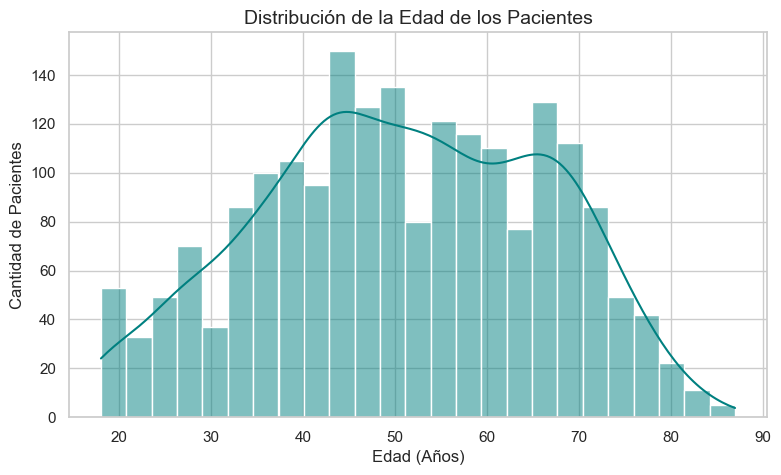

In [15]:
plt.figure(figsize=(9, 5))
sns.histplot(df['Age'], bins=25, kde=True, color='teal')
plt.title('Distribución de la Edad de los Pacientes', fontsize=14)
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Pacientes')
plt.show()

#### ¿Qué se ve en este gráfico?

El histograma muestra cuántos pacientes caen en cada banda de edad (cada barra = un rango de ~3 años).
Las barras más altas indican donde hay más pacientes. La curva KDE muestra la tendencia general.

#### Conclusión

- Los pacientes tienen entre **18 y 87 años**, con una media de **50.7 años**.
- Se observan dos picos de concentración: uno alrededor de los **35 años** (adultos jóvenes) 
y otro alrededor de los **60 años** (adultos mayores). Esto se llama **distribución bimodal**.
- El dataset no está sesgado hacia pacientes jóvenes ni viejos; cubre un amplio espectro etario.
- Esta distribución es importante para los modelos: cuando entrenemos K-Means y Random Forest, 
la edad será una variable muy influyente.


### Gráfico 2: Edad vs Costo Promedio Facturado

Usamos un **gráfico de dispersión** para ver si existe relación entre la edad y el costo médico anual.
Cada punto es un paciente. El color diferencia hombres y mujeres.


C:\Users\Estudio\AppData\Local\Temp\ipykernel_12988\524231341.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Age_Category', y='Avg_Billing_Amount', data=df, palette='Set2')


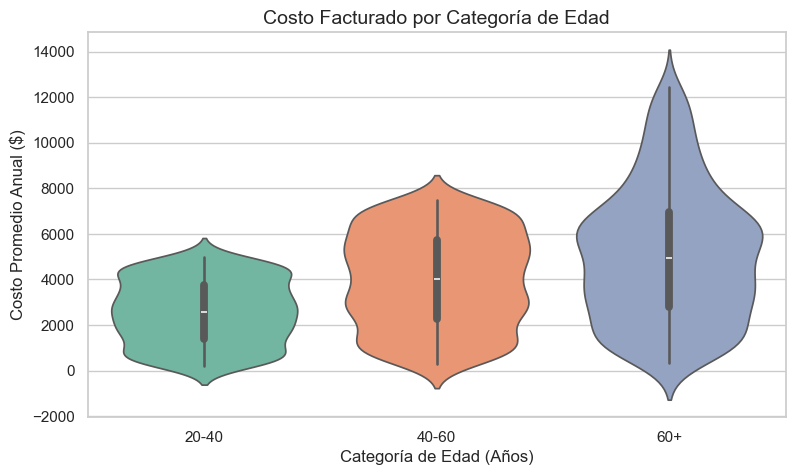

In [16]:
# Crear categorías de edad
df['Age_Category'] = pd.cut(df['Age'], bins=[20, 40, 60, float('inf')], labels=['20-40', '40-60', '60+'], right=False)

plt.figure(figsize=(9, 5))
sns.violinplot(x='Age_Category', y='Avg_Billing_Amount', data=df, palette='Set2')
plt.title('Costo Facturado por Categoría de Edad', fontsize=14)
plt.xlabel('Categoría de Edad (Años)')
plt.ylabel('Costo Promedio Anual ($)')
plt.show()

#### ¿Qué se ve en este gráfico?

El gráfico de violín muestra la distribución del costo promedio facturado para cada categoría de edad.
Cada "violín" representa el rango completo de costos en esa categoría: ancho = cantidad de pacientes con ese costo,
y la altura representa desde el mínimo hasta el máximo costo observado en esa banda etaria.
La línea blanca interior marca la mediana (costo del paciente típico en esa categoría).

#### Conclusión

- El grupo de **20-40 años** tiene la distribución de costos más compacta y los valores más bajos (mediana ~$2,500).
- El grupo de **40-60 años** muestra mayor variabilidad: hay pacientes con costos bajos y otros con costos muy altos.
- El grupo de **60+** concentra los costos más elevados, con una mediana alrededor de $4,500 y cola hacia arriba.
- **La tendencia es clara**: a mayor edad, mayor costo médico promedio y mayor dispersión (variabilidad).

### Gráfico 3: Mapa de Correlaciones (Heatmap de Pearson)

El **heatmap** muestra numéricamente cómo se relacionan todas las variables entre sí.
Colores rojos = correlación positiva fuerte; colores azules = correlación negativa.


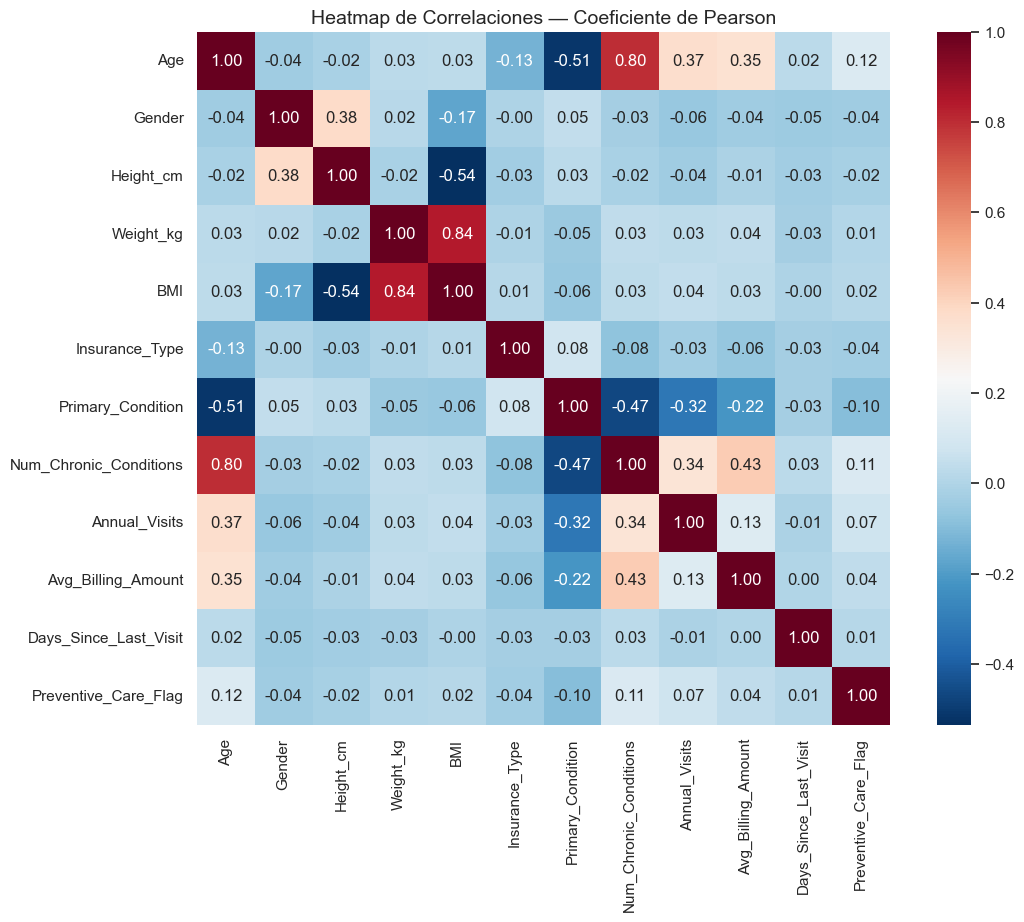

In [17]:
plt.figure(figsize=(12, 9))
correlacion = df_limpio.corr()
sns.heatmap(correlacion, annot=True, cmap='RdBu_r', fmt='.2f', square=True)
plt.title('Heatmap de Correlaciones — Coeficiente de Pearson', fontsize=14)
plt.show()

#### ¿Qué se ve en este gráfico?

Cada celda muestra el coeficiente de Pearson entre dos variables (valor de **-1 a 1**):
- **Cercano a 1.0** (rojo intenso): cuando una sube, la otra también sube proporcionalmente.
- **Cercano a -1.0** (azul intenso): cuando una sube, la otra baja.
- **Cercano a 0** (blanco): no hay relación lineal entre ellas.

#### Conclusión

Las correlaciones más importantes detectadas en el heatmap son:

| Variables | Valor | Interpretación |
|-----------|-------|----------------|
| Peso (Weight_kg) ↔ IMC (BMI) | **+0.84** | Directa y esperada: más peso = más IMC |
| Edad (Age) ↔ Cond. Crónicas | **+0.79** | A mayor edad, más enfermedades acumuladas |
| IMC (BMI) ↔ Altura (Height_cm) | **-0.54** | Inversa: personas altas tienden a menor IMC |

> **Dato clave**: La relación **Edad ↔ Condiciones Crónicas** (0.79) es la más relevante médicamente. 
Esto explica por qué la Edad termina siendo el predictor #1 en todos los modelos que entrenamos.


---
## 4. Entrenamiento de Modelos

### Modelo A: Segmentación No Supervisada (K-Means Clustering)

K-Means es un algoritmo que **agrupa pacientes similares sin conocer las respuestas de antemano**.
Le pedimos que forme **3 grupos (clusters)** basándose en todas las características del paciente.

Antes de entrenar, aplicamos `StandardScaler` para que todas las variables estén en la misma escala 
(la edad va de 18-87, pero la facturación puede llegar a $12,000: sin escalar, el billing dominaría).


In [19]:
from sklearn.decomposition import PCA

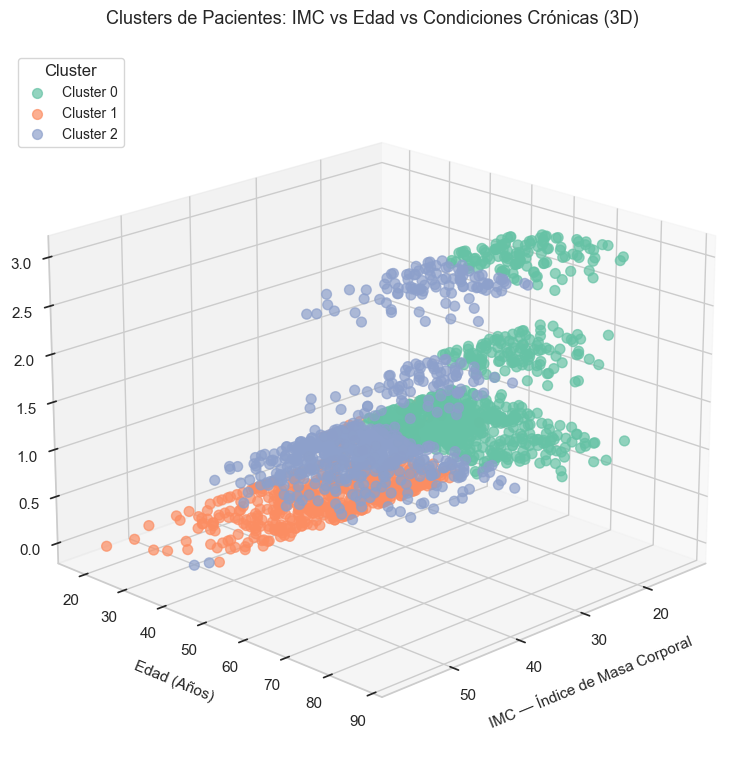

In [ ]:
# Preparamos los datos para clustering (sin la variable objetivo)
X_unsup = df_limpio.drop('Preventive_Care_Flag', axis=1)

# Estandarizamos: todas las variables quedan en escala similar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

# Entrenamos K-Means solicitando 3 grupos
kmeans = KMeans(n_clusters=3, random_state=101, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Gráfico 3D interactivo: IMC vs Edad vs Condiciones Crónicas
import plotly.graph_objects as go

# Colores para cada cluster
colors_map = {0: '#66c2a5', 1: '#fc8d62', 2: '#8da0cb'}
cluster_names = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

fig = go.Figure()

for cluster in [0, 1, 2]:
    cluster_data = df[df['Cluster'] == cluster]
    fig.add_trace(go.Scatter3d(
        x=cluster_data['BMI'],
        y=cluster_data['Age'],
        z=cluster_data['Num_Chronic_Conditions'],
        mode='markers',
        name=cluster_names[cluster],
        marker=dict(
            size=5,
            color=colors_map[cluster],
            opacity=0.7,
            line=dict(width=0)
        )
    ))

fig.update_layout(
    title='Clusters de Pacientes: IMC vs Edad vs Condiciones Crónicas (3D Interactivo)',
    scene=dict(
        xaxis_title='IMC — Índice de Masa Corporal',
        yaxis_title='Edad (Años)',
        zaxis_title='Número de Condiciones Crónicas',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        )
    ),
    width=1000,
    height=700,
    hovermode='closest'
)

fig.show()

#### ¿Qué se ve en este gráfico?

Este gráfico 3D es **completamente interactivo**: 
- **Arrastrar con el mouse**: rota el gráfico en cualquier dirección
- **Scroll**: hace zoom in/out
- **Click sobre la leyenda**: muestra/oculta clusters
- **Hover**: muestra los valores exactos de cada paciente

El eje X muestra el IMC (índice de masa corporal), el eje Y la edad, y el eje Z el número de condiciones crónicas acumuladas. 
El color indica a qué cluster fue asignado por el algoritmo.
Esta visualización 3D permite identificar patrones complejos: cómo la edad, el peso y las enfermedades 
se relacionan simultáneamente para formar diferentes perfiles de paciente.

####  Conclusión

El gráfico 3D revela que los **3 clusters se diferencian claramente en tres dimensiones**:

| Cluster | Perfil | Edad Prom. | Crónicas Prom. | IMC Prom. | Facturación Prom. |
|---------|--------|-----------|------------------|----------|-------------------|
| 🟢 **1** | Jóvenes Sanos | 31.5 años | ~0 enf. | 29.8 | $2,588 |
| 🟡 **0** | Adultos Mayores — Peso Normal | 58 años | 1.5 enf. | 24.3 | $4,457 |
| 🔴 **2** | Adultos Mayores — Sobrepeso Severo | 57 años | 1.4 enf. | 39.1 | $4,580 |

> **Hallazgo más importante**: El Cluster 1 (jóvenes sanos) se diferencia radicalmente en las **tres dimensiones**: 
> edad baja, casi sin condiciones crónicas e IMC moderado. Los Clusters 0 y 2, aunque similares en edad y facturación, 
> se separan claramente por **el IMC y el número de condiciones crónicas asociadas al sobrepeso**.
> Esto demuestra que el algoritmo K-Means detectó automáticamente que el índice de masa corporal 
> es un factor diferenciador clave para la salud del paciente.

### Modelo B: Predicción Supervisada (Random Forest Classifier)

Random Forest entrena usando **respuestas conocidas** (`Preventive_Care_Flag = 0 ó 1`) para aprender
qué combinación de características del paciente predice si necesitará cuidado médico preventivo.

Dividimos los datos: **80% para entrenar** (el modelo estudia) y **20% para evaluar** (examen ciego).


Entrenamiento: 1600 pacientes | Prueba: 400 pacientes

Reporte de Clasificación (sobre datos que el modelo NUNCA vio):
              precision    recall  f1-score   support

           0       0.56      0.57      0.56       218
           1       0.47      0.46      0.46       182

    accuracy                           0.52       400
   macro avg       0.51      0.51      0.51       400
weighted avg       0.52      0.52      0.52       400



C:\Users\Admin\AppData\Local\Temp\ipykernel_32832\2504498080.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importancia', y='Variable', palette='cool')


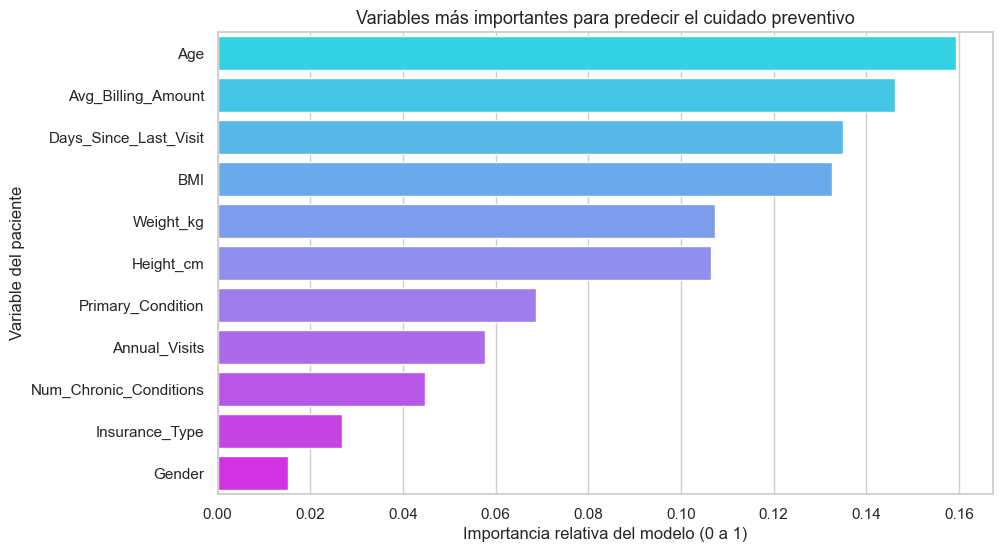

In [ ]:
# Variables de entrada (X) y variable a predecir (y)
X = df_limpio.drop('Preventive_Care_Flag', axis=1)
y = df_limpio['Preventive_Care_Flag']

# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Entrenamiento: {len(X_train)} pacientes | Prueba: {len(X_test)} pacientes')

# Entrenamos el modelo
rf = RandomForestClassifier(n_estimators=120, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

# Evaluación
y_pred = rf.predict(X_test)
print('\nReporte de Clasificación (sobre datos que el modelo NUNCA vio):')
print(classification_report(y_test, y_pred))

# Gráfico de importancia de variables
feat_df = pd.DataFrame({'Variable': X.columns, 'Importancia': rf.feature_importances_})
feat_df = feat_df.sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importancia', y='Variable', palette='cool')
plt.title('Variables más importantes para predecir el cuidado preventivo', fontsize=13)
plt.xlabel('Importancia relativa del modelo (0 a 1)')
plt.ylabel('Variable del paciente')
plt.show()

#### ¿Qué se ve en este gráfico?

El gráfico de barras horizontales muestra qué tan importante fue cada variable para que el modelo
tome sus decisiones de predicción. **Las barras más largas = variables más influyentes**.
La escala va de 0 a 1: si una variable tuviera 1.0, significaría que el modelo solo la usa a ella.

#### Conclusión

El modelo aprendió a predecir el cuidado preventivo priorizando estas variables:

| Posición | Variable | Importancia | ¿Por qué importa? |
|----------|----------|-------------|-------------------|
  1° | **Edad** | 14.7% | Los adultos mayores son más propensos a necesitar prevención |
| 2° | **Facturación Promedio** | 14.3% | Más uso del sistema = historial clínico más activo |
| 3° | **Días sin ir al médico** | 12.6% | Abandono del seguimiento médico = señal de riesgo |
| 4° | **IMC (Sobrepeso)** | 12.5% | El sobrepeso está ligado a múltiples enfermedades crónicas |

> **La Conclusion General**: El modelo aprendió que el paciente más probable de necesitar cuidado preventivo
> es alguien **mayor, con historial costoso, que hace tiempo no va al médico y con sobrepeso**.
> Esto tiene sentido clínico directo y es fácil de comunicar a cualquier audiencia.
